<a href="https://colab.research.google.com/github/Herrera1022/Modelo_afluencia_metro_pruebas/blob/main/gradient_boosting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Herrera1022/Modelo_afluencia_metro_pruebas.git
import os
os.chdir("Modelo_afluencia_metro_pruebas")
!ls

Cloning into 'Modelo_afluencia_metro_pruebas'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (113/113), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 113 (delta 63), reused 64 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (113/113), 13.68 MiB | 10.39 MiB/s, done.
Resolving deltas: 100% (63/63), done.
 afluencia_metro_2024_transformado.csv	'Paper primera entrega.pdf'
 Afluencia_Metro_2024.xlsx		 README.md
 Exploracion_inicial.ipynb		 regresion.ipynb
 knn_model.ipynb			 splits


In [2]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.utils import resample
import matplotlib.pyplot as plt

In [3]:
X_train      = pd.read_csv("./splits/X_train.csv")
y_train      = pd.read_csv("./splits/y_train.csv").squeeze()

X_validation = pd.read_csv("./splits/X_validation.csv")
y_validation = pd.read_csv("./splits/y_validation.csv").squeeze()

X_test       = pd.read_csv("./splits/X_test.csv")
y_test       = pd.read_csv("./splits/y_test.csv").squeeze()

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_validation.shape}")
print(f"Test:       {X_test.shape}")

Train:      (59899, 22)
Validation: (6947, 22)
Test:       (13611, 22)


## Búsqueda de hiperparámetros — Malla inicial (exploración rápida)
Probamos combinaciones representativas para identificar la zona de mejores hiperparámetros sin agotar el tiempo de cómputo.

In [4]:
# Malla exploratoria
param_grid = [
    {"n_estimators": 100, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.1},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05},
    {"n_estimators": 200, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 7, "learning_rate": 0.05},
]

resultados = []

for i, params in enumerate(param_grid):
    print(f"[{i+1}/{len(param_grid)}] Probando: {params}")

    modelo = GradientBoostingRegressor(
        n_estimators  = params["n_estimators"],
        max_depth     = params["max_depth"],
        learning_rate = params["learning_rate"],
        random_state  = 42
    )
    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_val   = modelo.predict(X_validation)

    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_val   = np.sqrt(mean_squared_error(y_validation, pred_val))
    mape_val   = mean_absolute_percentage_error(y_validation, pred_val) * 100

    resultados.append({
        "n_estimators":  params["n_estimators"],
        "max_depth":     params["max_depth"],
        "learning_rate": params["learning_rate"],
        "RMSE_train":    round(rmse_train, 2),
        "RMSE_val":      round(rmse_val, 2),
        "MAPE_val":      round(mape_val, 2)
    })

    print(f"   → RMSE train: {rmse_train:.2f} | RMSE val: {rmse_val:.2f} | MAPE val: {mape_val:.2f}%")

df_resultados = pd.DataFrame(resultados)
print("\n=== RESULTADOS ORDENADOS POR RMSE VALIDACIÓN ===")
print(df_resultados.sort_values("RMSE_val").to_string(index=False))

[1/8] Probando: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
   → RMSE train: 1149.05 | RMSE val: 1182.52 | MAPE val: 284.68%
[2/8] Probando: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
   → RMSE train: 779.46 | RMSE val: 1167.69 | MAPE val: 193.92%
[3/8] Probando: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
   → RMSE train: 1001.91 | RMSE val: 1159.95 | MAPE val: 211.18%
[4/8] Probando: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
   → RMSE train: 612.32 | RMSE val: 1179.33 | MAPE val: 152.71%
[5/8] Probando: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
   → RMSE train: 1145.46 | RMSE val: 1158.53 | MAPE val: 277.62%
[6/8] Probando: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}
   → RMSE train: 794.54 | RMSE val: 1190.01 | MAPE val: 194.19%
[7/8] Probando: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}
   → RMSE train: 691.40 | RMSE val: 1203.61 | MAPE val: 167.82%
[8/8] Probando

## Búsqueda de hiperparámetros — Malla refinada
Con base en la fase 1, identificamos que max_depth=7 y learning_rate=0.05 son prometedores. Refinamos explorando más estimadores y learning_rate más bajo.

In [5]:
param_grid_2 = [
    {"n_estimators": 300, "max_depth": 7, "learning_rate": 0.05},
    {"n_estimators": 400, "max_depth": 7, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 7, "learning_rate": 0.05},
    {"n_estimators": 300, "max_depth": 7, "learning_rate": 0.01},
    {"n_estimators": 500, "max_depth": 7, "learning_rate": 0.01},
    {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.01},
    {"n_estimators": 500, "max_depth": 5, "learning_rate": 0.01},
]

resultados_2 = []

for i, params in enumerate(param_grid_2):
    print(f"[{i+1}/{len(param_grid_2)}] Probando: {params}")

    modelo = GradientBoostingRegressor(
        n_estimators  = params["n_estimators"],
        max_depth     = params["max_depth"],
        learning_rate = params["learning_rate"],
        random_state  = 42
    )
    modelo.fit(X_train, y_train)

    pred_train = modelo.predict(X_train)
    pred_val   = modelo.predict(X_validation)

    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_val   = np.sqrt(mean_squared_error(y_validation, pred_val))
    mape_val   = mean_absolute_percentage_error(y_validation, pred_val) * 100

    resultados_2.append({
        "n_estimators":  params["n_estimators"],
        "max_depth":     params["max_depth"],
        "learning_rate": params["learning_rate"],
        "RMSE_train":    round(rmse_train, 2),
        "RMSE_val":      round(rmse_val, 2),
        "MAPE_val":      round(mape_val, 2)
    })

    print(f"   → RMSE train: {rmse_train:.2f} | RMSE val: {rmse_val:.2f} | MAPE val: {mape_val:.2f}%")

df_resultados_2 = pd.DataFrame(resultados_2)

# Combinar ambas mallas para ver el panorama completo
df_todos = pd.concat([df_resultados, df_resultados_2], ignore_index=True)

print("\n=== TODOS LOS RESULTADOS ORDENADOS POR RMSE VALIDACIÓN ===")
print(df_todos.sort_values("RMSE_val").to_string(index=False))

[1/7] Probando: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}
   → RMSE train: 411.70 | RMSE val: 1149.93 | MAPE val: 94.92%
[2/7] Probando: {'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.05}
   → RMSE train: 369.98 | RMSE val: 1152.84 | MAPE val: 82.06%
[3/7] Probando: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05}
   → RMSE train: 340.68 | RMSE val: 1154.21 | MAPE val: 77.45%
[4/7] Probando: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01}
   → RMSE train: 896.11 | RMSE val: 1242.89 | MAPE val: 545.46%
[5/7] Probando: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.01}
   → RMSE train: 612.19 | RMSE val: 1125.25 | MAPE val: 185.06%
[6/7] Probando: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01}
   → RMSE train: 1180.13 | RMSE val: 1285.73 | MAPE val: 708.30%
[7/7] Probando: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01}
   → RMSE train: 939.01 | RMSE val: 1196.96 | MAPE val: 345.31%

=== TODOS LOS 

## Modelo final con mejores hiperparámetros: n_estimators=500, max_depth=7, learning_rate=0.01

In [6]:
# Modelo final
modelo_final = GradientBoostingRegressor(
    n_estimators  = 500,
    max_depth     = 7,
    learning_rate = 0.01,
    random_state  = 42
)
modelo_final.fit(X_train, y_train)

# Predicciones
pred_train = modelo_final.predict(X_train)
pred_val   = modelo_final.predict(X_validation)
pred_test  = modelo_final.predict(X_test)

# Métricas
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_val   = np.sqrt(mean_squared_error(y_validation, pred_val))
rmse_test  = np.sqrt(mean_squared_error(y_test, pred_test))

mape_train = mean_absolute_percentage_error(y_train, pred_train) * 100
mape_val   = mean_absolute_percentage_error(y_validation, pred_val) * 100
mape_test  = mean_absolute_percentage_error(y_test, pred_test) * 100

print("=== MÉTRICAS MODELO FINAL GRADIENT BOOSTING ===")
print(f"RMSE  → Train: {rmse_train:.2f} | Val: {rmse_val:.2f} | Test: {rmse_test:.2f}")
print(f"MAPE  → Train: {mape_train:.2f}% | Val: {mape_val:.2f}% | Test: {mape_test:.2f}%")

=== MÉTRICAS MODELO FINAL GRADIENT BOOSTING ===
RMSE  → Train: 612.19 | Val: 1125.25 | Test: 1317.13
MAPE  → Train: 241.45% | Val: 185.06% | Test: 169.37%


In [7]:
n_bootstrap = 500
rmse_bootstrap = []

for i in range(n_bootstrap):
    indices = resample(range(len(y_validation)), random_state=i)
    rmse_b = np.sqrt(mean_squared_error(
        y_validation.iloc[indices],
        pred_val[indices]
    ))
    rmse_bootstrap.append(rmse_b)

ic_lower = np.percentile(rmse_bootstrap, 2.5)
ic_upper = np.percentile(rmse_bootstrap, 97.5)

print(f"RMSE Validación: {rmse_val:.2f}")
print(f"Intervalo de confianza 95%: [{ic_lower:.2f}, {ic_upper:.2f}]")
print(f"Expresado como: {rmse_val:.2f} ± {((ic_upper - ic_lower)/2):.2f}")

RMSE Validación: 1125.25
Intervalo de confianza 95%: [735.53, 1452.99]
Expresado como: 1125.25 ± 358.73


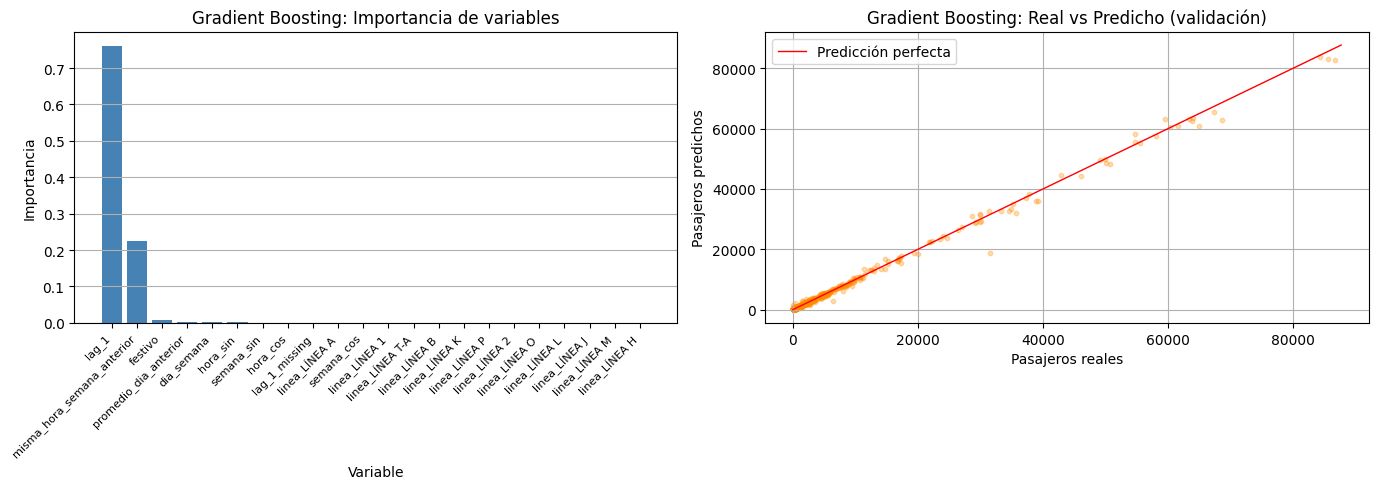

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Importancia de variables
importancias = modelo_final.feature_importances_
nombres = X_train.columns
indices = np.argsort(importancias)[::-1]

axes[0].bar(range(len(nombres)), importancias[indices], color="steelblue")
axes[0].set_xticks(range(len(nombres)))
axes[0].set_xticklabels(nombres[indices], rotation=45, ha="right", fontsize=8)
axes[0].set_xlabel("Variable")
axes[0].set_ylabel("Importancia")
axes[0].set_title("Gradient Boosting: Importancia de variables")
axes[0].grid(axis="y")

# Gráfica 2: Real vs Predicho en validación
sample_idx = np.random.choice(len(y_validation), size=1000, replace=False)
axes[1].scatter(
    y_validation.iloc[sample_idx],
    pred_val[sample_idx],
    alpha=0.3, s=10, color="darkorange"
)
max_val = max(y_validation.max(), pred_val.max())
axes[1].plot([0, max_val], [0, max_val], color="red", linewidth=1, label="Predicción perfecta")
axes[1].set_xlabel("Pasajeros reales")
axes[1].set_ylabel("Pasajeros predichos")
axes[1].set_title("Gradient Boosting: Real vs Predicho (validación)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()